##Prediksi Kualitas Kopi Arabika dan Robusta Menggunakan Algoritma Ensemble Learning Berdasarkan Karakteristik Sensori (Coffee Quality Institute Dataset)

##Install Library

In [5]:
!pip install gradio scikit-learn pandas numpy matplotlib seaborn xgboost shap -q
print("Semua library berhasil diinstall!")

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'd:\\Kuliah\\Semester 6\\Proyek Data Mining\\Project UTS\\.venv\\Lib\\site-packages\\scipy\\sparse\\_sparsetools.cp311-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'd:\\Kuliah\\Semester 6\\Proyek Data Mining\\Project UTS\\.venv\\Lib\\site-packages\\scipy\\linalg\\tests\\test_matfuncs.py'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua library berhasil diinstall!


##Load Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, roc_auc_score)
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

url_arabica = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"
url_robusta = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/robusta_data_cleaned.csv"

df_arabica = pd.read_csv(url_arabica)
df_robusta = pd.read_csv(url_robusta)

# Tambahkan kolom species
df_arabica['Species'] = 'Arabica'
df_robusta['Species'] = 'Robusta'

# Samakan kolom yang ada di keduanya
kolom_bersama = list(set(df_arabica.columns) & set(df_robusta.columns))
df = pd.concat([df_arabica[kolom_bersama], df_robusta[kolom_bersama]], ignore_index=True)

print("✅ Dataset berhasil dimuat!")
print(f"📊 Total data    : {df.shape[0]} sampel kopi")
print(f"📊 Total fitur   : {df.shape[1]} kolom")
print(f"🫘 Arabica       : {len(df_arabica)} sampel")
print(f"🫘 Robusta       : {len(df_robusta)} sampel")
print(f"\n📋 Kolom tersedia:")
for col in df.columns:
    print(f"   • {col}")
df.head()

ModuleNotFoundError: No module named 'pandas'

## EDA (Exploratory Data Analysis)


Kolom sensori yang digunakan:
['Flavor', 'Aftertaste', 'Balance', 'Clean.Cup', 'Cupper.Points']
📌 DISTRIBUSI KUALITAS KOPI
Kualitas
⭐ Specialty            1127
✅ Good Quality          179
🏆 Specialty Premium      25
⚠️ Below Standard         7
Name: count, dtype: int64

📊 Statistik Total Cup Points:
   Min    : 59.83
   Max    : 90.58
   Mean   : 82.15
   Median : 82.50


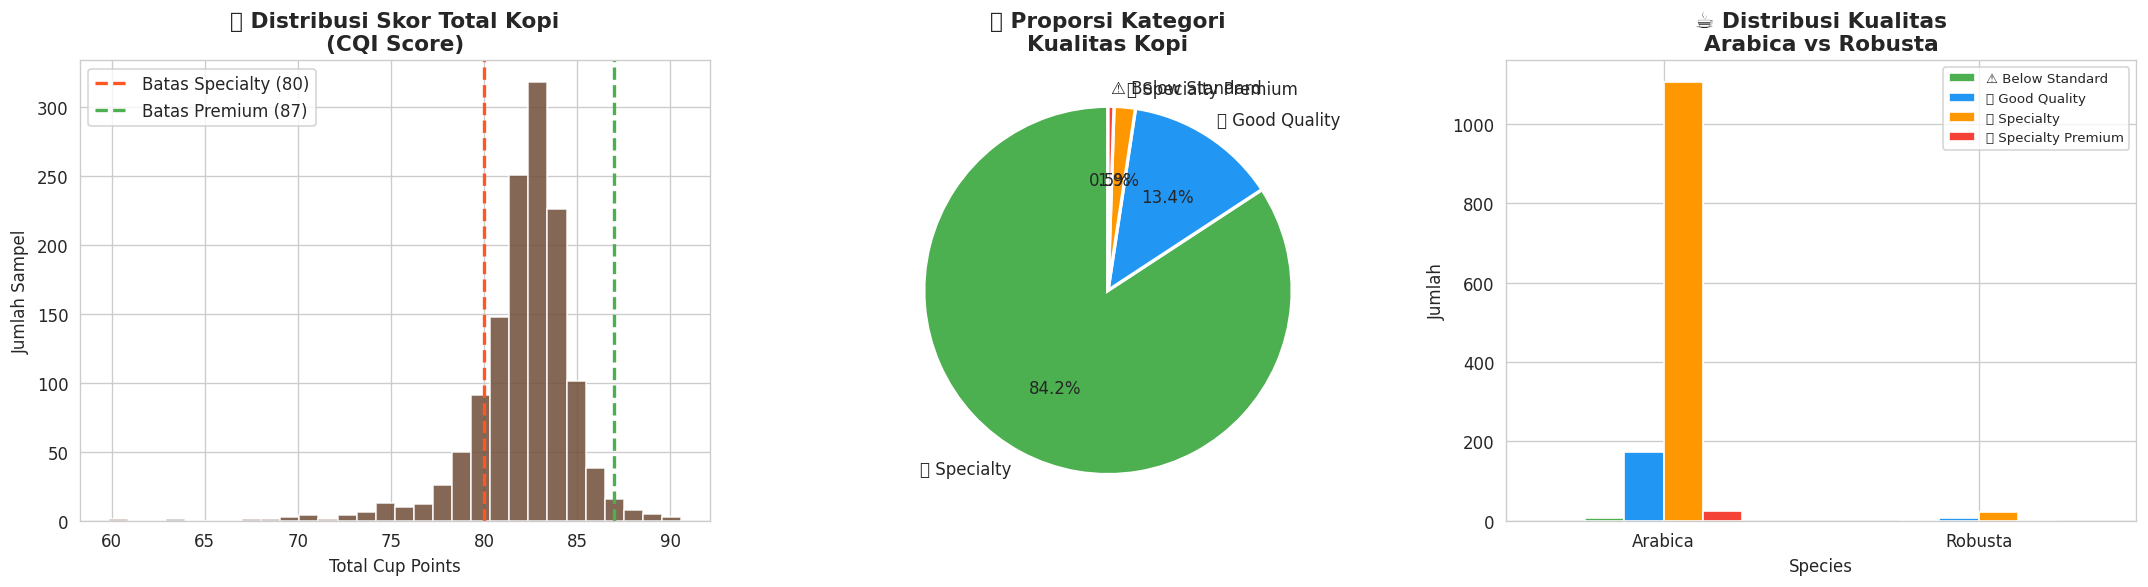

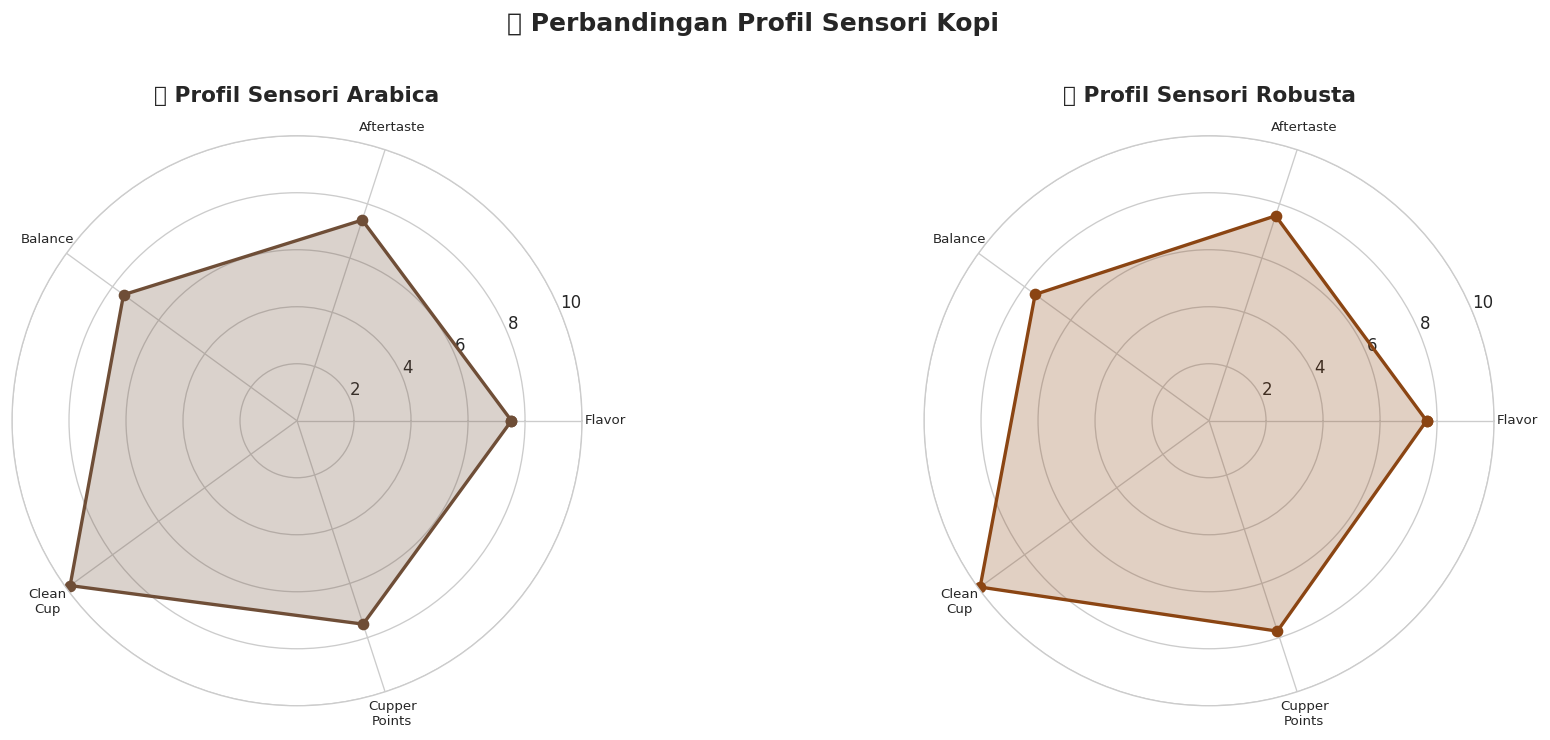

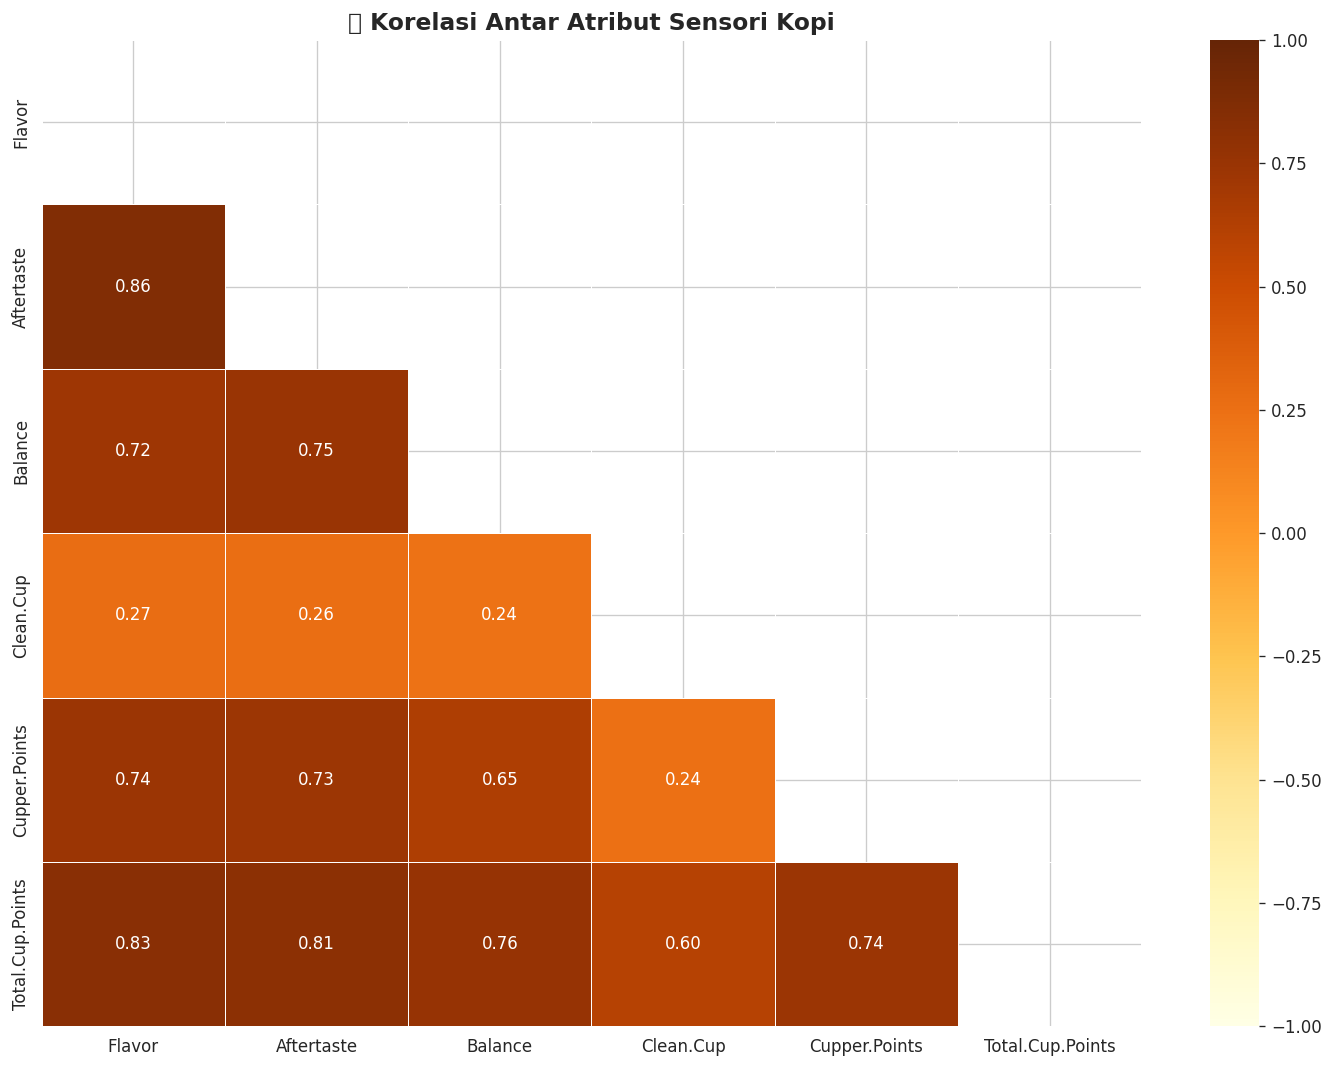

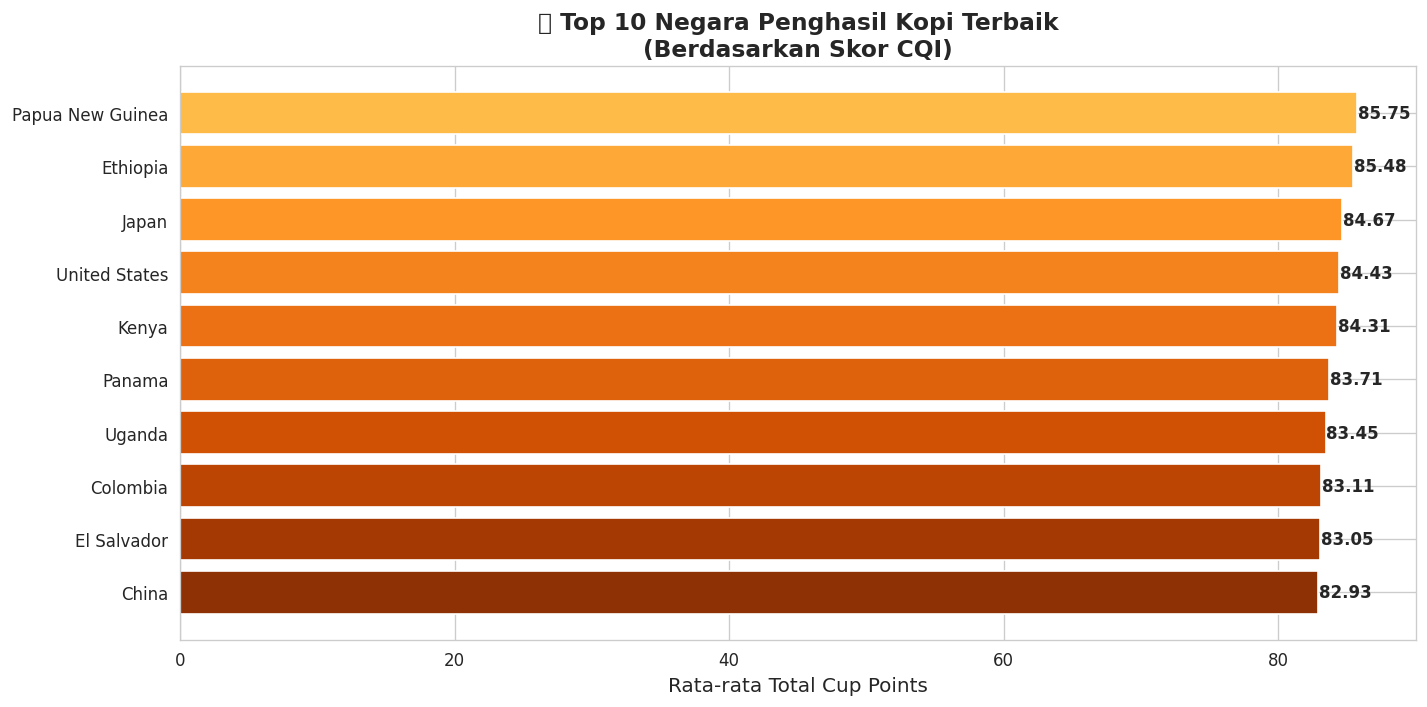

In [ ]:
# ============================================================
# EDA - EXPLORATORY DATA ANALYSIS
# ============================================================

# Kolom sensori utama
sensori = [col for col in [
    'Aroma', 'Flavor', 'Aftertaste',
    'Acidity', 'Body', 'Balance',
    'Uniformity', 'Clean.Cup',
    'Sweetness', 'Cupper.Points'
] if col in df.columns]

print("Kolom sensori yang digunakan:")
print(sensori)

# Hapus baris tanpa Total.Cup.Points
df = df.dropna(subset=['Total.Cup.Points'])
df = df[df['Total.Cup.Points'] > 0]

# ---- Buat Kolom Target: Kategori Kualitas ----
def kategori_kopi(score):
    if score >= 87:
        return '🏆 Specialty Premium'
    elif score >= 80:
        return '⭐ Specialty'
    elif score >= 70:
        return '✅ Good Quality'
    else:
        return '⚠️ Below Standard'

df['Kualitas'] = df['Total.Cup.Points'].apply(kategori_kopi)

print("=" * 60)
print("📌 DISTRIBUSI KUALITAS KOPI")
print("=" * 60)
print(df['Kualitas'].value_counts())

print(f"\n📊 Statistik Total Cup Points:")
print(f"   Min    : {df['Total.Cup.Points'].min():.2f}")
print(f"   Max    : {df['Total.Cup.Points'].max():.2f}")
print(f"   Mean   : {df['Total.Cup.Points'].mean():.2f}")
print(f"   Median : {df['Total.Cup.Points'].median():.2f}")

# ============================================================
# VISUALISASI 1: Distribusi Skor & Kategori
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram Skor Kopi
axes[0].hist(df['Total.Cup.Points'], bins=30,
             color='#6F4E37', edgecolor='white', alpha=0.85)
axes[0].axvline(80, color='#FF5722', linestyle='--',
                linewidth=2, label='Batas Specialty (80)')
axes[0].axvline(87, color='#4CAF50', linestyle='--',
                linewidth=2, label='Batas Premium (87)')
axes[0].set_title('📊 Distribusi Skor Total Kopi\n(CQI Score)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].legend()

# Pie Chart Kategori
colors_kopi = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
kualitas_count = df['Kualitas'].value_counts()
axes[1].pie(kualitas_count, labels=kualitas_count.index,
            autopct='%1.1f%%', colors=colors_kopi,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('🫘 Proporsi Kategori\nKualitas Kopi',
                   fontsize=13, fontweight='bold')

# Bar Chart per Species
species_quality = df.groupby(['Species', 'Kualitas']).size().unstack(fill_value=0)
species_quality.plot(kind='bar', ax=axes[2],
                     color=colors_kopi, edgecolor='white')
axes[2].set_title('☕ Distribusi Kualitas\nArabica vs Robusta',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Species')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_kualitas_kopi.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 2: Profil Sensori Kopi (Radar Chart)
# ============================================================
df_sensori = df[sensori].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw=dict(polar=True))

def radar_chart(ax, values, title, color):
    N = len(sensori)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values = list(values) + [values[0]]
    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([s.replace('.', '\n') for s in sensori], size=8)
    ax.set_title(title, size=13, fontweight='bold', pad=20)
    ax.set_ylim(0, 10)

arabica_mean = df[df['Species'] == 'Arabica'][sensori].mean()
robusta_mean = df[df['Species'] == 'Robusta'][sensori].mean()

radar_chart(axes[0], arabica_mean, '🫘 Profil Sensori Arabica', '#6F4E37')
radar_chart(axes[1], robusta_mean, '🫘 Profil Sensori Robusta', '#8B4513')

plt.suptitle('🎯 Perbandingan Profil Sensori Kopi',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('radar_sensori.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 3: Heatmap Korelasi Fitur Sensori
# ============================================================
plt.figure(figsize=(12, 9))
sensori_corr = df[sensori + ['Total.Cup.Points']].corr()
mask = np.triu(np.ones_like(sensori_corr, dtype=bool))
sns.heatmap(sensori_corr, annot=True, fmt='.2f',
            cmap='YlOrBr', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('🔗 Korelasi Antar Atribut Sensori Kopi',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 4: Top 10 Negara Penghasil Kopi Terbaik
# ============================================================
if 'Country.of.Origin' in df.columns:
    top_country = df.groupby('Country.of.Origin')['Total.Cup.Points'] \
                    .mean().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    colors_country = plt.cm.YlOrBr(np.linspace(0.4, 0.9, len(top_country)))
    bars = plt.barh(top_country.index[::-1], top_country.values[::-1],
                    color=colors_country[::-1], edgecolor='white')
    for bar, val in zip(bars, top_country.values[::-1]):
        plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
    plt.xlabel('Rata-rata Total Cup Points', fontsize=12)
    plt.title('🌍 Top 10 Negara Penghasil Kopi Terbaik\n(Berdasarkan Skor CQI)',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('top_negara_kopi.png', dpi=150, bbox_inches='tight')
    plt.show()

## Preprocessing

⚙️  TAHAP PREPROCESSING

📋 Fitur Numerik  : ['Flavor', 'Aftertaste', 'Balance', 'Clean.Cup', 'Cupper.Points']
📋 Fitur Kategori : ['Species', 'Processing.Method', 'Color']

🔧 Step 1: Handling Missing Value
   Processing.Method: 169 nilai → diisi 'Unknown'
   Color: 270 nilai → diisi 'Unknown'
   ✅ Missing value selesai ditangani!

🔧 Step 2: Encoding Variabel Kategorikal
   Species: ['Arabica' 'Robusta']... → encoded ✅
   Processing.Method: ['Natural / Dry' 'Other' 'Pulped natural / honey'
 'Semi-washed / Semi-pulped' 'Unknown']... → encoded ✅
   Color: ['Blue-Green' 'Bluish-Green' 'Green' 'Unknown']... → encoded ✅

🔧 Step 3: Encoding Target
   Mapping: {'⚠️ Below Standard': 0, '✅ Good Quality': 1, '⭐ Specialty': 2, '🏆 Specialty Premium': 3}

🔧 Step Tambahan: SMOTE Balancing

📊 Distribusi target setelah SMOTE:
target
3    1127
2    1127
1    1127
0    1127
Name: count, dtype: int64

📊 Jumlah fitur  : 8
📊 Jumlah sampel : 4508

📊 Distribusi Target:
   ⚠️ Below Standard: 1127 sampel
   ✅ Go

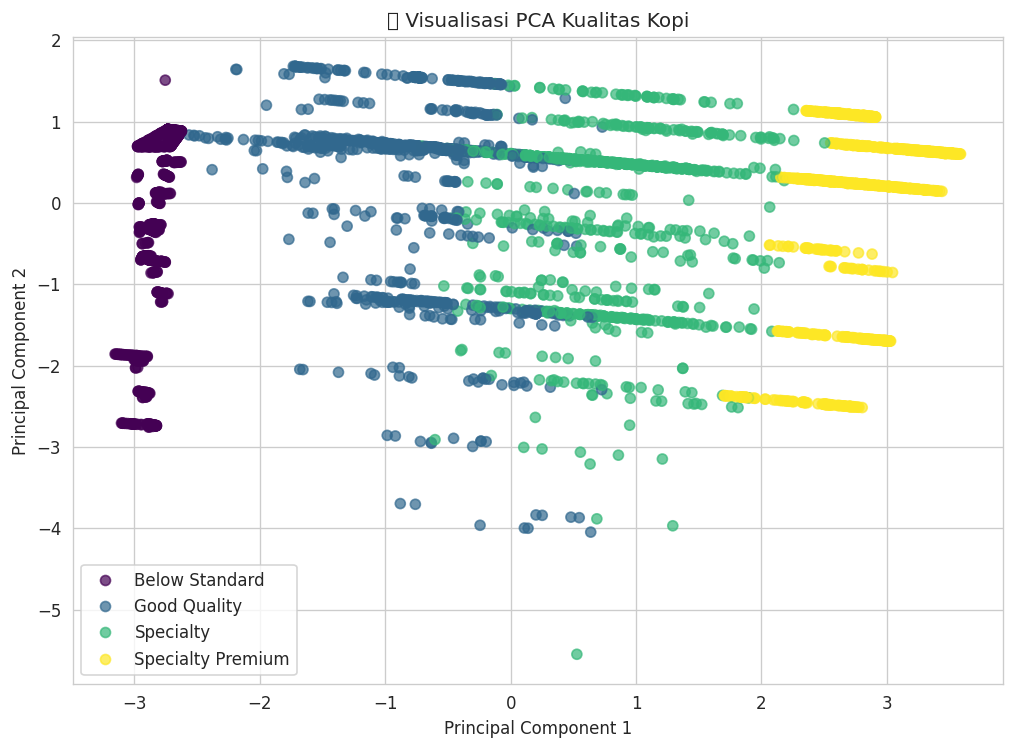


✅ Preprocessing selesai! Data siap dimodelkan.


In [ ]:
# ============================================================
# PREPROCESSING
# ============================================================

print("=" * 60)
print("⚙️  TAHAP PREPROCESSING")
print("=" * 60)

df_model = df.copy()

# ---- Pilih Fitur untuk Model ----
fitur_numerik = [col for col in sensori if col in df_model.columns]
fitur_kat     = ['Species', 'Processing.Method', 'Color']
fitur_kat     = [col for col in fitur_kat if col in df_model.columns]

print(f"\n📋 Fitur Numerik  : {fitur_numerik}")
print(f"📋 Fitur Kategori : {fitur_kat}")

# ---- Step 1: Tangani Missing Value ----
print("\n🔧 Step 1: Handling Missing Value")
for col in fitur_numerik:
    n = df_model[col].isnull().sum()
    if n > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)
        print(f"   {col}: {n} nilai → diisi median")
for col in fitur_kat:
    n = df_model[col].isnull().sum()
    if n > 0:
        df_model[col].fillna('Unknown', inplace=True)
        print(f"   {col}: {n} nilai → diisi 'Unknown'")
print("   ✅ Missing value selesai ditangani!")

# ---- Step 2: Encoding Kategorikal ----
print("\n🔧 Step 2: Encoding Variabel Kategorikal")
le_dict = {}
for col in fitur_kat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"   {col}: {le.classes_[:5]}... → encoded ✅")

# ---- Step 3: Encode Target ----
print("\n🔧 Step 3: Encoding Target")
target_map = {
    '⚠️ Below Standard'  : 0,
    '✅ Good Quality'     : 1,
    '⭐ Specialty'        : 2,
    '🏆 Specialty Premium': 3
}
target_map_inv = {v: k for k, v in target_map.items()}
df_model['target'] = df_model['Kualitas'].map(target_map)
print(f"   Mapping: {target_map}")

# ---- Hapus baris dengan target NaN ----
df_model = df_model.dropna(subset=['target'])
df_model['target'] = df_model['target'].astype(int)

# ---- Step 4: Buat X dan y ----
semua_fitur = fitur_numerik + fitur_kat
X = df_model[semua_fitur]
y = df_model['target']

# ============================================================
# SMOTE - HANDLE CLASS IMBALANCE
# ============================================================

from imblearn.over_sampling import SMOTE

print("\n🔧 Step Tambahan: SMOTE Balancing")

smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

print("\n📊 Distribusi target setelah SMOTE:")
print(pd.Series(y).value_counts())

print(f"\n📊 Jumlah fitur  : {len(semua_fitur)}")
print(f"📊 Jumlah sampel : {len(X)}")
print(f"\n📊 Distribusi Target:")
for k, v in target_map.items():
    print(f"   {k}: {(y == v).sum()} sampel")

# ---- Step 5: Train-Test Split (80:20) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n📊 Data Training  : {len(X_train)} sampel (80%)")
print(f"📊 Data Testing   : {len(X_test)} sampel (20%)")

# ---- Step 6: Feature Scaling ----
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ============================================================
# PCA VISUALIZATION
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_s)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("📉 Visualisasi PCA Kualitas Kopi")

legend_labels = [
    'Below Standard',
    'Good Quality',
    'Specialty',
    'Specialty Premium'
]

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=legend_labels
)

plt.grid(True)
plt.show()

print("\n✅ Preprocessing selesai! Data siap dimodelkan.")

## Modelling & Evaluasi

🤖 TRAINING & EVALUASI MODEL

🌲 Random Forest
   Akurasi  : 99.00%
   F1-Score : 99.00%
   CV Score : 98.53%

⚡ XGBoost
   Akurasi  : 98.89%
   F1-Score : 98.89%
   CV Score : 98.09%

🚀 Gradient Boosting
   Akurasi  : 99.11%
   F1-Score : 99.11%
   CV Score : 98.50%

📉 Logistic Regression
   Akurasi  : 96.56%
   F1-Score : 96.55%
   CV Score : 96.09%

🏆 Model Terbaik: 🚀 Gradient Boosting (99.11%)

📋 Classification Report:

                   precision    recall  f1-score   support

   Below Standard       1.00      1.00      1.00       226
     Good Quality       0.99      0.98      0.99       225
        Specialty       0.97      0.99      0.98       226
Specialty Premium       1.00      0.99      1.00       225

         accuracy                           0.99       902
        macro avg       0.99      0.99      0.99       902
     weighted avg       0.99      0.99      0.99       902



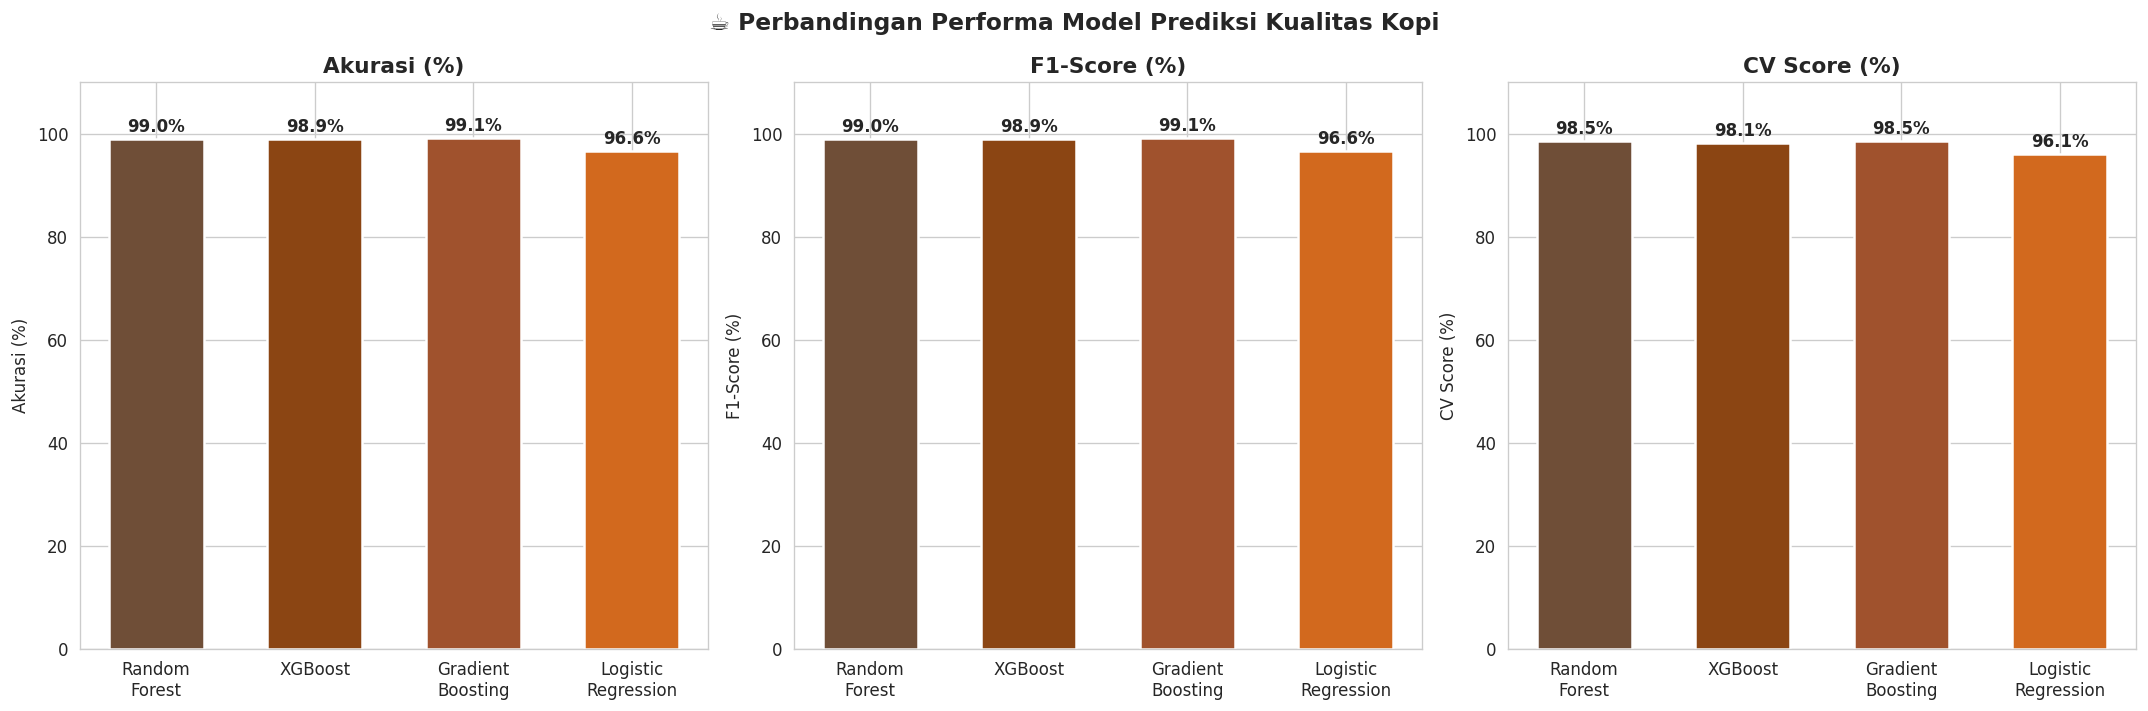

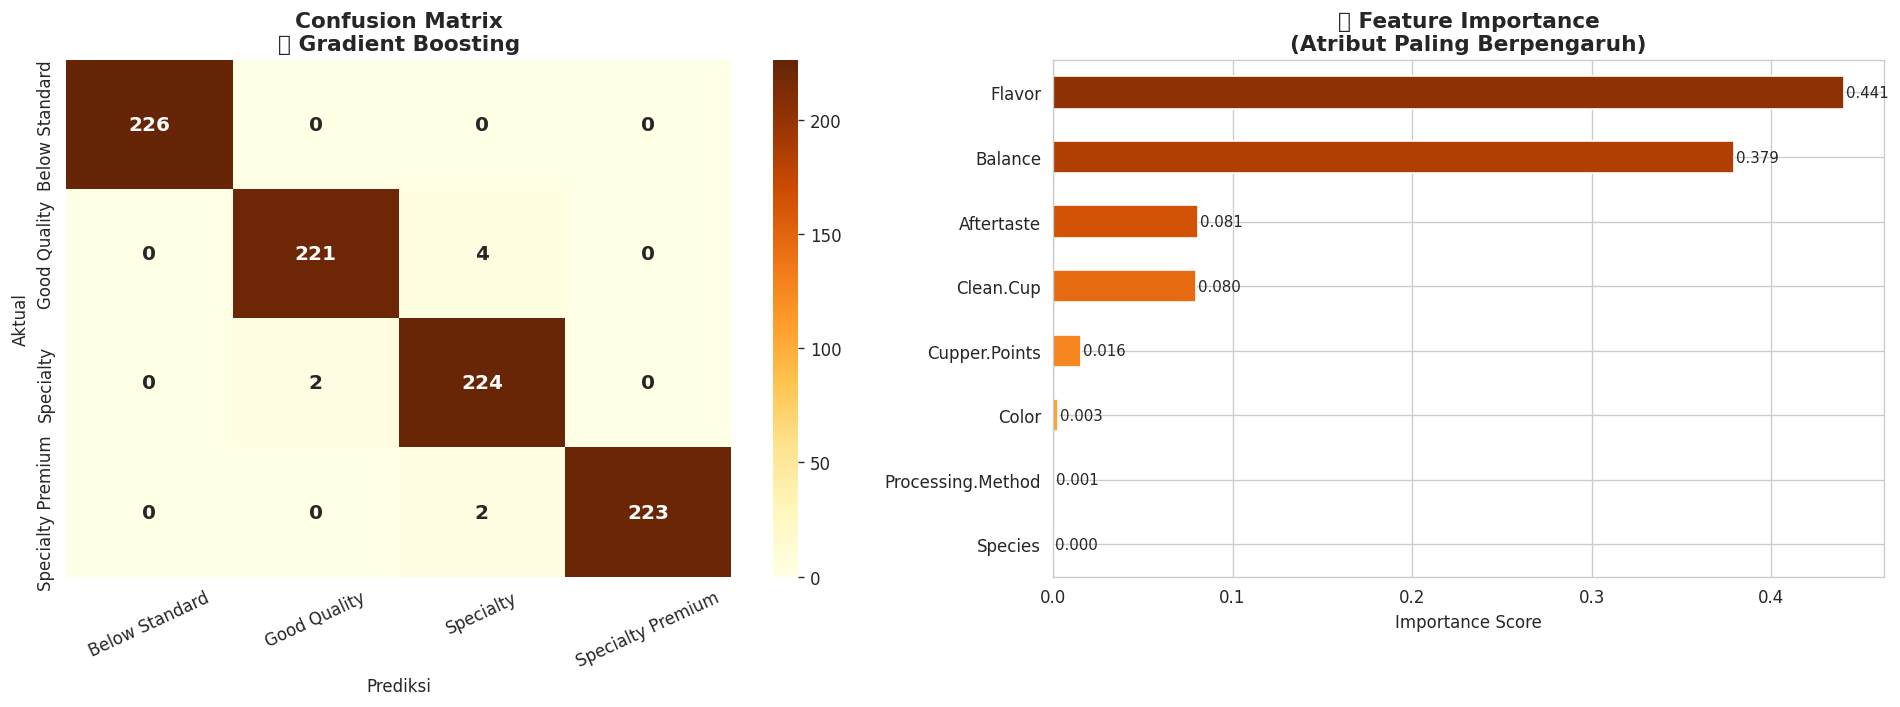


🔍 Menghitung SHAP Values (Interpretasi Model)...


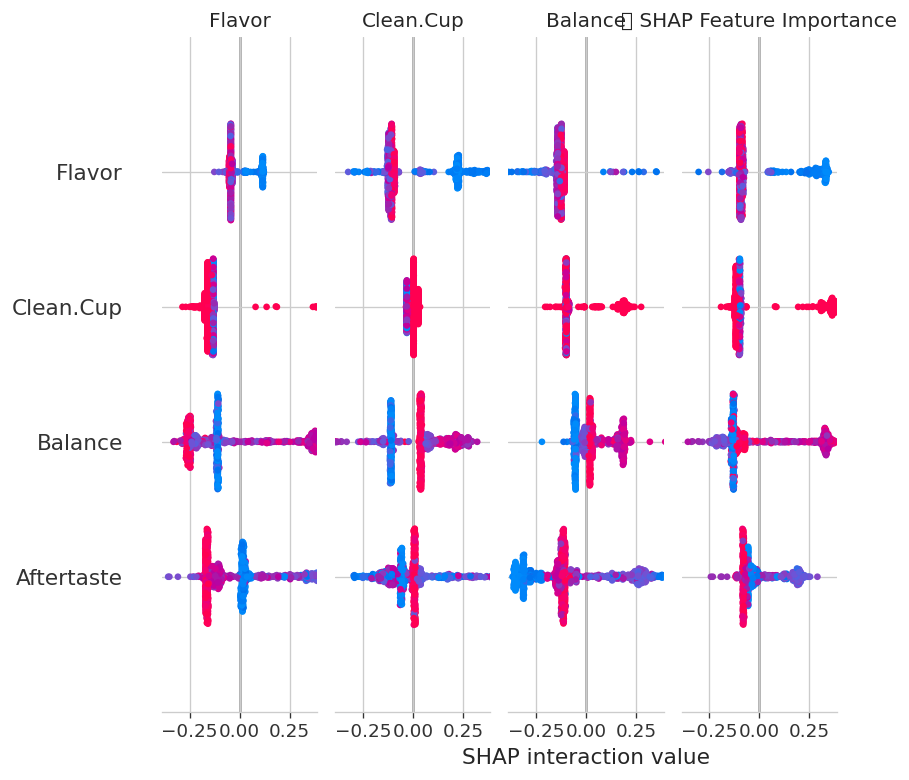

✅ SHAP Values berhasil dihitung!

✅ Evaluasi selesai! Model terbaik: 🚀 Gradient Boosting (99.11%)


In [ ]:
# ============================================================
# MODELLING - 4 ALGORITMA
# ============================================================

models = {
    '🌲 Random Forest'      : RandomForestClassifier(
                                n_estimators=300,
                                max_depth=20,
                                random_state=42),

    '⚡ XGBoost'            : XGBClassifier(
                                n_estimators=300,
                                max_depth=6,
                                learning_rate=0.05,
                                random_state=42,
                                verbosity=0,
                                use_label_encoder=False,
                                eval_metric='mlogloss'),

    '🚀 Gradient Boosting'  : GradientBoostingClassifier(
                                n_estimators=200,
                                max_depth=5,
                                random_state=42),

    '📉 Logistic Regression': LogisticRegression(
                                max_iter=2000,
                                random_state=42,
                                multi_class='auto')
}

hasil = {}
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("🤖 TRAINING & EVALUASI MODEL")
print("=" * 60)

for nama, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    y_pred = mdl.predict(X_test_s)
    acc    = accuracy_score(y_test, y_pred) * 100
    f1     = f1_score(y_test, y_pred, average='weighted') * 100
    cv     = cross_val_score(mdl, X_train_s, y_train,
                             cv=skf, scoring='accuracy').mean() * 100
    hasil[nama] = {'model': mdl, 'y_pred': y_pred,
                   'acc': acc, 'f1': f1, 'cv': cv}
    print(f"\n{nama}")
    print(f"   Akurasi  : {acc:.2f}%")
    print(f"   F1-Score : {f1:.2f}%")
    print(f"   CV Score : {cv:.2f}%")

# ---- Pilih Model Terbaik ----
best_name = max(hasil, key=lambda x: hasil[x]['acc'])
best      = hasil[best_name]
best_mdl  = best['model']
label_names = ['Below Standard', 'Good Quality', 'Specialty', 'Specialty Premium']

print(f"\n{'='*60}")
print(f"🏆 Model Terbaik: {best_name} ({best['acc']:.2f}%)")
print(f"{'='*60}")
print(f"\n📋 Classification Report:\n")
print(classification_report(y_test, best['y_pred'], target_names=label_names))

# ============================================================
# VISUALISASI 1: Perbandingan Model
# ============================================================
nama_list   = list(hasil.keys())
nama_pendek = ['Random\nForest', 'XGBoost', 'Gradient\nBoosting', 'Logistic\nRegression']
warna_bar   = ['#6F4E37', '#8B4513', '#A0522D', '#D2691E']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric, title in zip(
    axes,
    ['acc', 'f1', 'cv'],
    ['Akurasi (%)', 'F1-Score (%)', 'CV Score (%)']
):
    vals = [hasil[n][metric] for n in nama_list]
    bars = ax.bar(nama_pendek, vals, color=warna_bar,
                  edgecolor='white', linewidth=1.5, width=0.6)
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('☕ Perbandingan Performa Model Prediksi Kualitas Kopi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 2: Confusion Matrix
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            ax=axes[0], xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix\n{best_name}',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')
axes[0].tick_params(axis='x', rotation=25)

# Feature Importance
if hasattr(best_mdl, 'feature_importances_'):
    fi = pd.Series(best_mdl.feature_importances_,
                   index=semua_fitur).sort_values(ascending=True)
    colors_fi = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(fi)))
    fi.plot(kind='barh', color=colors_fi, ax=axes[1],
            edgecolor='white', linewidth=1)
    axes[1].set_title('🔑 Feature Importance\n(Atribut Paling Berpengaruh)',
                       fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Importance Score')
    for i, v in enumerate(fi.values):
        axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('cm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 3: SHAP Values (interpretasi AI)
# ============================================================

print("\n🔍 Menghitung SHAP Values (Interpretasi Model)...")

try:

    # Gunakan Random Forest untuk SHAP
    shap_model = hasil['🌲 Random Forest']['model']

    explainer = shap.TreeExplainer(shap_model)

    shap_values = explainer.shap_values(X_test_s)

    # Untuk multiclass ambil rata-rata absolute SHAP
    shap.summary_plot(
        shap_values,
        X_test_s,
        feature_names=semua_fitur,
        show=False
    )

    plt.title("🧠 SHAP Feature Importance")
    plt.tight_layout()
    plt.show()

    print("✅ SHAP Values berhasil dihitung!")

except Exception as e:
    print(f"SHAP skip: {e}")

print(f"\n✅ Evaluasi selesai! Model terbaik: {best_name} ({best['acc']:.2f}%)")

## Deployment Gradio

In [ ]:
# ============================================================
# DEPLOYMENT - WEB APP INTERAKTIF
# ============================================================
import gradio as gr

def prediksi_kualitas_kopi(aroma, flavor, aftertaste, acidity,
                            body, balance, uniformity,
                            clean_cup, sweetness, cupper_points,
                            species, processing_method):

    # Encode kategorikal
    sp_encoded  = le_dict['Species'].transform([species])[0] \
                  if 'Species' in le_dict else 0
    proc_encoded = le_dict['Processing.Method'] \
                   .transform([processing_method])[0] \
                   if 'Processing.Method' in le_dict else 0

    input_data = pd.DataFrame([[
        aroma, flavor, aftertaste, acidity, body,
        balance, uniformity, clean_cup, sweetness,
        cupper_points, sp_encoded, proc_encoded
    ]], columns=semua_fitur[:12])

    input_s = scaler.transform(input_data)
    pred    = best_mdl.predict(input_s)[0]
    proba   = best_mdl.predict_proba(input_s)[0]

    label_emoji = {
        0: ('⚠️', 'BELOW STANDARD', '#F44336'),
        1: ('✅', 'GOOD QUALITY',   '#2196F3'),
        2: ('⭐', 'SPECIALTY',       '#FF9800'),
        3: ('🏆', 'SPECIALTY PREMIUM', '#4CAF50')
    }

    em, lb, _ = label_emoji[pred]
    total_est  = aroma+flavor+aftertaste+acidity+body+balance \
                 +uniformity+clean_cup+sweetness+cupper_points

    result = f"""
## {em} Hasil: **{lb}**
### Estimasi Total Cup Points: **{total_est:.1f} / 100**

---

### 📊 Probabilitas Tiap Kategori:
| Kategori | Probabilitas |
|----------|-------------|
| 🏆 Specialty Premium | **{proba[3]*100:.1f}%** |
| ⭐ Specialty          | **{proba[2]*100:.1f}%** |
| ✅ Good Quality       | **{proba[1]*100:.1f}%** |
| ⚠️ Below Standard    | **{proba[0]*100:.1f}%** |

---

### 💡 Analisa Profil Kopi Ini:
"""
    if pred == 3:
        result += "🏆 **Kopi kelas dunia!** Layak dipamerkan di kompetisi internasional."
    elif pred == 2:
        result += "⭐ **Kopi specialty berkualitas tinggi.** Cocok untuk specialty coffee shop."
    elif pred == 1:
        result += "✅ **Kopi berkualitas baik.** Masih bisa ditingkatkan pada aspek balance & aftertaste."
    else:
        result += "⚠️ **Perlu peningkatan.** Fokus pada proses pengolahan dan penyimpanan biji kopi."

    return result

# ---- Bangun UI Gradio ----
kopi_img = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/240px-A_small_cup_of_coffee.JPG"

with gr.Blocks(
    title="☕ Coffee Quality Predictor",
    theme=gr.themes.Soft(primary_hue="orange")
) as app:

    gr.Markdown("""
    # ☕ Coffee Quality Prediction System
    ### Prediksi Kualitas Kopi Arabika & Robusta
    > 🤖 Berbasis **Machine Learning** dengan dataset **Coffee Quality Institute (CQI)**
    ---
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 🫘 Spesifikasi Kopi")
            species = gr.Dropdown(
                choices=['Arabica', 'Robusta'],
                value='Arabica', label="🌿 Species")
            processing = gr.Dropdown(
                choices=['Washed / Wet', 'Natural / Dry',
                         'Pulped natural / honey', 'Semi-washed'],
                value='Washed / Wet', label="⚙️ Processing Method")

            gr.Markdown("### 🎯 Atribut Sensori (Skala 0–10)")
            aroma      = gr.Slider(0, 10, value=7.5, step=0.25, label="👃 Aroma")
            flavor     = gr.Slider(0, 10, value=7.5, step=0.25, label="👅 Flavor")
            aftertaste = gr.Slider(0, 10, value=7.2, step=0.25, label="🔄 Aftertaste")
            acidity    = gr.Slider(0, 10, value=7.3, step=0.25, label="🍋 Acidity")
            body       = gr.Slider(0, 10, value=7.4, step=0.25, label="💪 Body")
            balance    = gr.Slider(0, 10, value=7.3, step=0.25, label="⚖️ Balance")
            uniformity = gr.Slider(0, 10, value=9.8, step=0.25, label="🔁 Uniformity")
            clean_cup  = gr.Slider(0, 10, value=9.8, step=0.25, label="🫙 Clean Cup")
            sweetness  = gr.Slider(0, 10, value=9.8, step=0.25, label="🍯 Sweetness")
            cupper     = gr.Slider(0, 10, value=7.5, step=0.25, label="☕ Cupper Points")

            btn = gr.Button("☕ Analisa Kualitas Kopi!", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 🏅 Hasil Prediksi")
            output = gr.Markdown("*Isi parameter kopi di kiri, lalu klik tombol Analisa...*")

    gr.Markdown(f"""
    ---
    ### 📊 Info Sistem
    | Info | Detail |
    |---|---|
    | 🏆 Algoritma | {best_name} |
    | 📈 Akurasi | {best['acc']:.2f}% |
    | 📊 F1-Score | {best['f1']:.2f}% |
    | 🫘 Dataset | Coffee Quality Institute (CQI) |
    | 📦 Total Sampel | {len(df)} kopi |
    | 🌍 Asal Data | 30+ negara penghasil kopi |
    """)

    btn.click(
        fn=prediksi_kualitas_kopi,
        inputs=[aroma, flavor, aftertaste, acidity, body,
                balance, uniformity, clean_cup, sweetness,
                cupper, species, processing],
        outputs=output
    )

print("🚀 Meluncurkan aplikasi Coffee Quality Predictor...")
app.launch(share=True)

🚀 Meluncurkan aplikasi Coffee Quality Predictor...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://19c1ae7f57bbc75cbf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
